# CE444: Geotechnical Design, Homework Assignment 5


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sy
from icecream import ic

## Problem 1

Solved on paper.

## Problem 2

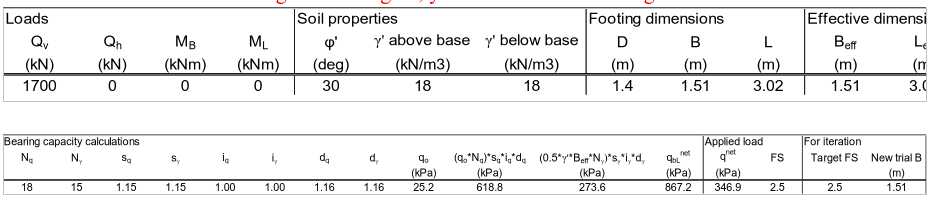

Correct answer: For friction angle of 45 degree, you should be calculating a foundation width of 0.47 m.

In [2]:
phis = np.linspace(30, 45, 16)
phiR = (np.pi/180) * phis
print(phis)
print(phiR)

[30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45.]
[0.52359878 0.54105207 0.55850536 0.57595865 0.59341195 0.61086524
 0.62831853 0.64577182 0.66322512 0.68067841 0.6981317  0.71558499
 0.73303829 0.75049158 0.76794487 0.78539816]


In [3]:
# known values based on variables

saftey = 2.5
gamma_soil = 18 # kN/m^3
z_embed = 1.4 # m
q0 = gamma_soil * z_embed # kPa

i_q = 1
i_gamma = 1

s_q = (1 + (0.1/2) * ((1 + np.sin(np.radians(phis)))/ (1 - np.sin(np.radians(phis)))))
s_gamma = s_q

N_q = ((1 + np.sin(np.radians(phis)) )/ (1 - np.sin(np.radians(phis))) ) * np.exp(np.pi * np.tan(np.radians(phis)))

N_gamma = 1.5* (N_q - 1) * np.tan(np.radians(phis))

ic(saftey, gamma_soil, z_embed, q0, i_q, i_gamma, s_q, s_gamma, N_q, N_gamma)

ic| saftey: 2.5
    gamma_soil: 18
    z_embed: 1.4
    q0: 25.2
    i_q: 1
    i_gamma: 1
    s_q: array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
                1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
                1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
                1.29142136])
    s_gamma: array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
                    1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
                    1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
                    1.29142136])
    N_q: array([ 18.40112222,  20.63079316,  23.17677621,  26.0920121 ,
                 29.43979237,  33.29609149,  37.75249717,  42.91991165,
                 48.9332527 ,  55.95745874,  64.19520639,  73.89689143,
                 85.37362303,  99.01425896, 115.30790234, 134.87384063])
    N_gamma: array([ 15.0698139 ,  17.6930558 ,  20.78638166,  24.44241478,
              

(2.5,
 18,
 1.4,
 25.2,
 1,
 1,
 array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
        1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
        1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
        1.29142136]),
 array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
        1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
        1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
        1.29142136]),
 array([ 18.40112222,  20.63079316,  23.17677621,  26.0920121 ,
         29.43979237,  33.29609149,  37.75249717,  42.91991165,
         48.9332527 ,  55.95745874,  64.19520639,  73.89689143,
         85.37362303,  99.01425896, 115.30790234, 134.87384063]),
 array([ 15.0698139 ,  17.6930558 ,  20.78638166,  24.44241478,
         28.77432326,  33.92095008,  40.05337831,  47.38337881,
         56.17434205,  66.75550889,  79.54061156,  95.05245142,
        113.95552712, 137.09966271, 165.57878724, 200.81076094]))

In [10]:
# solvables 

B = sy.Symbol('B') 

widths = np.zeros(len(phis)) # initializing array
sin_frac = np.sqrt((1 + np.sin(phiR)) / (1 - np.sin(phiR)))
ic(sin_frac)

for i in range(len(widths)):
    depth_factor = (1 + (0.1*(z_embed/B)*sin_frac))
    surcharge_term = q0 * float(N_q[i]) * float(s_q[i]) * i_q * depth_factor[i]
    gamma_term = 0.5*gamma_soil*B*float(N_gamma[i])*float(s_gamma[i])*i_gamma * (depth_factor[i])
    q_bL_net_cap = ((1.7*10**3)/(2*B**2) - q0)*2.5
    widths[i] = sy.solve(surcharge_term + gamma_term - q0 - q_bL_net_cap)[0]

ic(widths)

ic| sin_frac: array([1.73205081,

 1.76749402, 1.80404776, 1.84177089, 1.88072647,
                     1.92098213, 1.96261051, 2.00568971, 2.05030384, 2.0965436 ,
                     2.14450692, 2.19429973, 2.24603677, 2.29984255, 2.35585237,
                     2.41421356])
ic| widths: array([1.51145397, 1.42201686, 1.33585339, 1.25285712, 1.17292768,
                   1.09597105, 1.02189972, 0.95063285, 0.88209651, 0.81622384,
                   0.75295536, 0.69223934, 0.63403229, 0.57829953, 0.52501597,
                   0.474167  ])


array([1.51145397, 1.42201686, 1.33585339, 1.25285712, 1.17292768,
       1.09597105, 1.02189972, 0.95063285, 0.88209651, 0.81622384,
       0.75295536, 0.69223934, 0.63403229, 0.57829953, 0.52501597,
       0.474167  ])

In [ ]:
# back calc to check FS = 2.5
q_bL_net_backcalc = np.zeros(len(phis))
q_bL_net_demand = np.zeros(len(phis))

depth_factor = (1 + (0.1*(z_embed/widths)*sin_frac))

print(1 + (0.1*(1.4/1.51146827646477)*(sin_frac[0])))

ic(depth_factor)
surcharge_term = q0 * N_q * s_q * i_q * depth_factor
gamma_term = 0.5*gamma_soil*widths*N_gamma*s_gamma*i_gamma*depth_factor
q_bL_net_backcalc = surcharge_term + gamma_term - q0
q_bL_net_demand = (1.7*10**3)/(2*widths**2) - q0

ic(q_bL_net_backcalc)
ic(q_bL_net_demand)

FS = q_bL_net_backcalc/q_bL_net_demand

ic(FS)


ic| FS: array([2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5,
               2.5, 2.5, 2.5])


1.1604314935585713


array([2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5,
       2.5, 2.5, 2.5])

In [27]:
problem2_table = pd.DataFrame({"phi": phis, "B": widths, "L": 2*widths, \
    "N_q": N_q, "s_q": s_q, "i_q": i_q, "d_q": depth_factor,\
    "N_gamma": N_gamma, "s_gamma": s_gamma,  "i_gamma": i_gamma, "d_gamma": depth_factor, \
    "q_bL_net_capacity": q_bL_net_backcalc, "q_bL_net_demand": q_bL_net_demand, "FS": np.round(FS,1)})

problem2_table.reset_index(drop=True, inplace=True)

In [28]:
problem2_table.to_latex()

'\\begin{tabular}{lrrrrrrrrrrrrrr}\n\\toprule\n & phi & B & L & N_q & s_q & i_q & d_q & N_gamma & s_gamma & i_gamma & d_gamma & q_bL_net_capacity & q_bL_net_demand & FS \\\\\n\\midrule\n0 & 30.000000 & 1.511454 & 3.022908 & 18.401122 & 1.150000 & 1 & 1.160433 & 15.069814 & 1.150000 & 1 & 1.160433 & 867.184461 & 346.873784 & 2.500000 \\\\\n1 & 31.000000 & 1.422017 & 2.844034 & 20.630793 & 1.156202 & 1 & 1.174013 & 17.693056 & 1.156202 & 1 & 1.174013 & 987.871092 & 395.148437 & 2.500000 \\\\\n2 & 32.000000 & 1.335853 & 2.671707 & 23.176776 & 1.162729 & 1 & 1.189068 & 20.786382 & 1.162729 & 1 & 1.189068 & 1127.806888 & 451.122755 & 2.500000 \\\\\n3 & 33.000000 & 1.252857 & 2.505714 & 26.092012 & 1.169606 & 1 & 1.205808 & 24.442415 & 1.169606 & 1 & 1.205808 & 1290.804155 & 516.321662 & 2.500000 \\\\\n4 & 34.000000 & 1.172928 & 2.345855 & 29.439792 & 1.176857 & 1 & 1.224482 & 28.774323 & 1.176857 & 1 & 1.224482 & 1481.601535 & 592.640614 & 2.500000 \\\\\n5 & 35.000000 & 1.095971 & 2.191942 

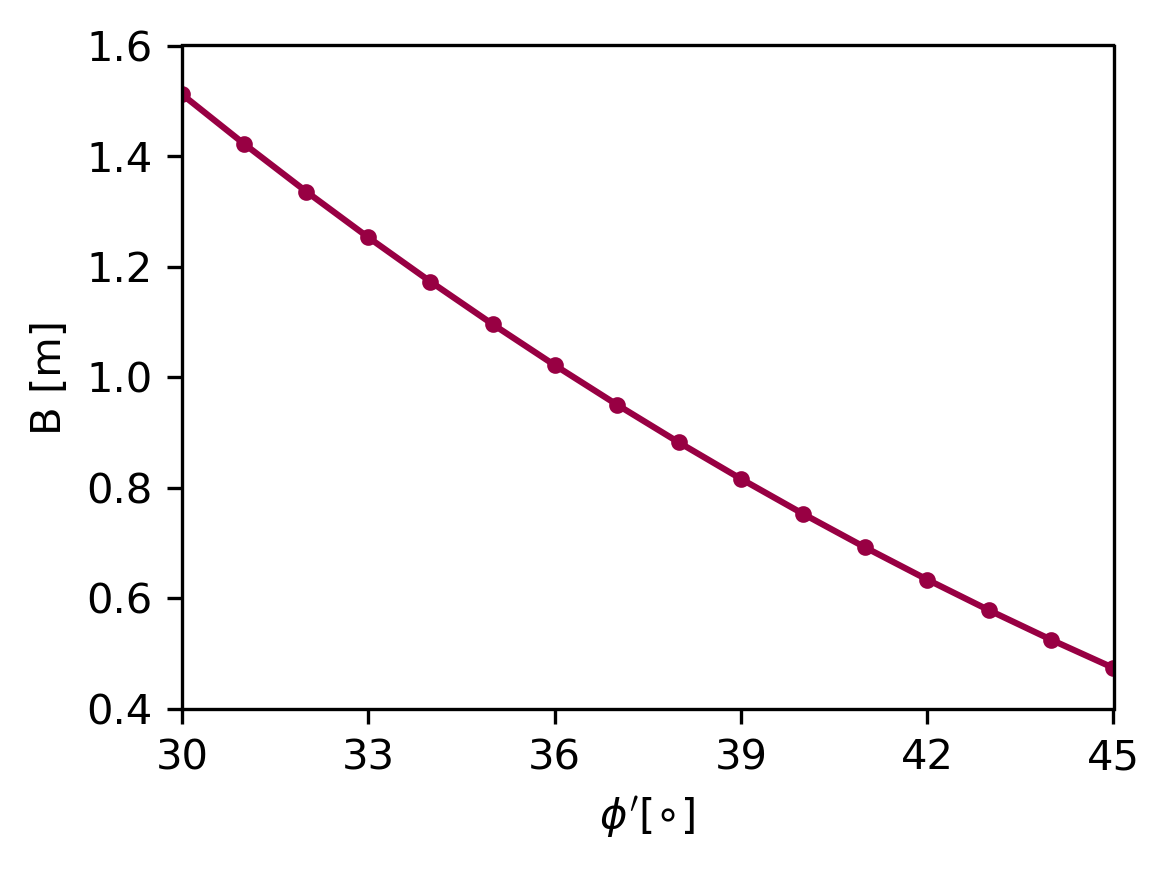

In [22]:
fig, ax = plt.subplots(figsize=(4,3), tight_layout = True, dpi = 300)

ax.plot(phis, widths, '.', linestyle = '-', color = "#980043" )
ax.set_xlabel("$\\phi' [\\circ]$")
ax.set_ylabel('B [m]')

ax.set_ylim(0.4, 1.6)
ax.set_xlim(30, 45)
ax.set_xticks(np.linspace(30, 45, 6))

## Problem 3

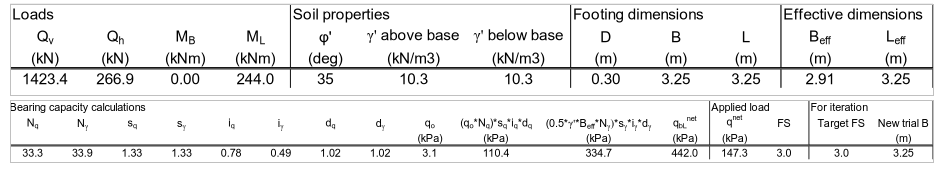